# E-Mobilität in Deutschland — Eine Datenanalyse

**Projektarbeit Woche 4 — Python-Weiterbildung educx**  
**Autor:** Alex  
**Datum:** Mai 2026

---

## Fragestellung

Wie hat sich die Elektromobilität in Deutschland im Zeitraum **Januar 2025 bis März 2026** entwickelt, und in welchem Verhältnis steht die öffentliche Ladeinfrastruktur zu den E-Auto-Beständen und -Neuzulassungen in den 16 Bundesländern?

Konkret untersuche ich:

1. Wie verteilen sich Ladepunkte und Ladeleistung über Deutschland?
2. Wie hat sich der BEV-Anteil an Neuzulassungen monatlich entwickelt?
3. Wie unterscheiden sich Bundesländer im Verhältnis "BEV-Bestand pro Ladepunkt"?
4. Wie groß ist die Lücke zwischen aktuellem Bestand und Neuzulassungs-Dynamik?

## Datenquellen

| Quelle | Inhalt | Stand |
|---|---|---|
| **Bundesnetzagentur** — Ladesäulenregister | Alle öffentlich gemeldeten Ladeeinrichtungen | 22.04.2026 |
| **KBA FZ 28.9** (15 Monatsdateien) | Pkw-Neuzulassungen nach Bundesländern und Antriebsarten | Jan 2025 – März 2026 |
| **KBA FZ 1.2** | Pkw-Bestand nach Bundesländern und Kraftstoffarten | 01.01.2026 |

Alle Datensätze sind offene Daten unter den jeweiligen Open-Data-Lizenzen.

## Methodik

- **Sprache:** Python 3.11
- **Bibliotheken:** pandas, numpy, matplotlib, seaborn
- **Vorgehen:** Einlesen → Aufbereitung → Aggregation → Verknüpfung → Visualisierung
- **Eigene Kennzahlen:** BEV je Ladepunkt, BEV-Anteil am Bestand (%), BEV-Anteil bei Neuzulassungen (%)

---


## 1. Setup & Bibliotheken

Wir laden die benötigten Bibliotheken und stellen die Anzeige-Optionen für `pandas` ein.

In [47]:
# Bibliotheken
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Anzeige-Optionen für Pandas (alle Spalten sehen, breitere Darstellung)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Plot-Stil
sns.set_theme(style="whitegrid")

print("Imports OK – pandas Version:", pd.__version__)

Imports OK – pandas Version: 3.0.3


In [48]:
import os

# Aktuelles Arbeitsverzeichnis des Notebooks
print("Notebook arbeitet in:", os.getcwd())
print()

# Was liegt hier?
print("Dateien/Ordner hier:")
for item in os.listdir():
    print("  ", item)

Notebook arbeitet in: c:\Users\Alex\Desktop\Weiterbildung\educx\01_Python\Projektarbeit Woche 4\notebooks

Dateien/Ordner hier:
   .ipynb_checkpoints
   emobility.ipynb
   emobility_final.ipynb


## 2. BNetzA-Datensatz: Ladesäulen einlesen

Die Bundesnetzagentur stellt das **Ladesäulenregister** öffentlich bereit. Es enthält alle öffentlich zugänglichen Ladeeinrichtungen in Deutschland, inkl. Betreiber, Standort, Nennleistung und Inbetriebnahmedatum.

Die CSV-Datei hat einen Vorspann mit Metadaten, den wir mit `skiprows` überspringen. Außerdem nutzt sie deutsche Zahlenformate (Komma als Dezimaltrennzeichen).

In [49]:
# Finale Einlesung – Vorspann überspringen, deutsche Zahlenformate korrekt parsen
pfad_ladesaeulen = "../data/ladesaeulen_bnetza.csv"

df_ladesaeulen = pd.read_csv(
    pfad_ladesaeulen,
    sep=";",                # Trennzeichen Semikolon
    encoding="cp1252",      # Windows-1252 für Umlaute
    skiprows=10,            # 10 Vorspann-Zeilen überspringen, Zeile 10 wird zum Header
    decimal=",",            # deutsches Dezimalformat (Komma statt Punkt)
    low_memory=False
)

print("Shape:", df_ladesaeulen.shape)
print()
print("Spalten:")
for spalte in df_ladesaeulen.columns:
    print(f"  - {spalte}")

Shape: (109646, 47)

Spalten:
  - Ladeeinrichtungs-ID
  - Betreiber
  - Anzeigename (Karte)
  - Status
  - Art der Ladeeinrichtung
  - Anzahl Ladepunkte
  - Nennleistung Ladeeinrichtung [kW]
  - Inbetriebnahmedatum
  - Straße
  - Hausnummer
  - Adresszusatz
  - Postleitzahl
  - Ort
  - Kreis/kreisfreie Stadt
  - Bundesland
  - Breitengrad
  - Längengrad
  - Standortbezeichnung
  - Informationen zum Parkraum
  - Bezahlsysteme
  - Öffnungszeiten
  - Öffnungszeiten: Wochentage
  - Öffnungszeiten: Tageszeiten
  - Steckertypen1
  - Nennleistung Stecker1
  - EVSE-ID1
  - Public Key1
  - Steckertypen2
  - Nennleistung Stecker2
  - EVSE-ID2
  - Public Key2
  - Steckertypen3
  - Nennleistung Stecker3
  - EVSE-ID3
  - Public Key3
  - Steckertypen4
  - Nennleistung Stecker4
  - EVSE-ID4
  - Public Key4
  - Steckertypen5
  - Nennleistung Stecker5
  - EVSE-ID5
  - Public Key5
  - Steckertypen6
  - Nennleistung Stecker6
  - EVSE-ID6
  - Public Key6


### 2.1 Erste Datensichtung

Bevor wir mit der Auswertung beginnen, verschaffen wir uns einen Überblick: Wie groß ist der Datensatz, welche Spalten gibt es, welche Datentypen?

In [50]:
# Dimensionen
print(f"Anzahl Zeilen: {df_ladesaeulen.shape[0]:,}")
print(f"Anzahl Spalten: {df_ladesaeulen.shape[1]}")
print()

# Spaltennamen
print("Spalten:")
for i, spalte in enumerate(df_ladesaeulen.columns):
    print(f"  {i:2d}: {spalte}")

Anzahl Zeilen: 109,646
Anzahl Spalten: 47

Spalten:
   0: Ladeeinrichtungs-ID
   1: Betreiber
   2: Anzeigename (Karte)
   3: Status
   4: Art der Ladeeinrichtung
   5: Anzahl Ladepunkte
   6: Nennleistung Ladeeinrichtung [kW]
   7: Inbetriebnahmedatum
   8: Straße
   9: Hausnummer
  10: Adresszusatz
  11: Postleitzahl
  12: Ort
  13: Kreis/kreisfreie Stadt
  14: Bundesland
  15: Breitengrad
  16: Längengrad
  17: Standortbezeichnung
  18: Informationen zum Parkraum
  19: Bezahlsysteme
  20: Öffnungszeiten
  21: Öffnungszeiten: Wochentage
  22: Öffnungszeiten: Tageszeiten
  23: Steckertypen1
  24: Nennleistung Stecker1
  25: EVSE-ID1
  26: Public Key1
  27: Steckertypen2
  28: Nennleistung Stecker2
  29: EVSE-ID2
  30: Public Key2
  31: Steckertypen3
  32: Nennleistung Stecker3
  33: EVSE-ID3
  34: Public Key3
  35: Steckertypen4
  36: Nennleistung Stecker4
  37: EVSE-ID4
  38: Public Key4
  39: Steckertypen5
  40: Nennleistung Stecker5
  41: EVSE-ID5
  42: Public Key5
  43: Steckertyp

In [51]:
df_ladesaeulen.info() #Zelle: Datentypen und fehlende Werte


<class 'pandas.DataFrame'>
RangeIndex: 109646 entries, 0 to 109645
Data columns (total 47 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Ladeeinrichtungs-ID                109646 non-null  int64  
 1   Betreiber                          109646 non-null  str    
 2   Anzeigename (Karte)                48528 non-null   str    
 3   Status                             109646 non-null  str    
 4   Art der Ladeeinrichtung            109646 non-null  str    
 5   Anzahl Ladepunkte                  109646 non-null  int64  
 6   Nennleistung Ladeeinrichtung [kW]  109646 non-null  float64
 7   Inbetriebnahmedatum                109646 non-null  str    
 8   Straße                             109646 non-null  str    
 9   Hausnummer                         109646 non-null  str    
 10  Adresszusatz                       18640 non-null   str    
 11  Postleitzahl                       109646 non-null

In [52]:
df_ladesaeulen.describe() #Zelle: Numerische Übersicht


,Ladeeinrichtungs-ID,Anzahl Ladepunkte,Nennleistung Ladeeinrichtung [kW],Postleitzahl,Breitengrad,Längengrad
count,1.096460e+05,109646.000000,109646.000000,109646.000000,109646.000000,109646.000000
mean,1.079520e+06,1.801498,76.295785,53882.543303,50.657209,9.697544
std,4.493142e+04,0.616748,99.312988,27221.700475,1.816621,2.055491
min,1.000000e+06,1.000000,1.000000,1011.000000,47.352641,5.853720
25%,1.040842e+06,1.000000,22.000000,30938.000000,48.970962,8.146919
50%,1.077080e+06,2.000000,44.000000,53359.000000,50.798700,9.449980
75%,1.119058e+06,2.000000,50.000000,78054.000000,52.141582,11.305365
max,1.154674e+06,6.000000,1200.000000,99996.000000,55.122778,15.000000


In [53]:
df_ladesaeulen.head(3).T   # .T = transponiert, damit alle Spalten lesbar untereinander stehen Zelle: Stichprobe ansehen


,0,1,2
Ladeeinrichtungs-ID,1010338,1063962,1063963
Betreiber,Albwerk Elektro- und Kommunikationstechnik GmbH,smopi® - Multi Chargepoint Solution GmbH,smopi® - Multi Chargepoint Solution GmbH
Anzeigename (Karte),Albwerk Elektro- und Kommunikationstechnik GmbH,smopi,smopi
Status,In Betrieb,In Betrieb,In Betrieb
Art der Ladeeinrichtung,Normalladeeinrichtung,Normalladeeinrichtung,Normalladeeinrichtung
Anzahl Ladepunkte,2,4,4
Nennleistung Ladeeinrichtung [kW],22.0,22.0,22.0
Inbetriebnahmedatum,11.01.2020,23.11.2022,23.11.2022
Straße,Am Berg,Albstraße,Albstraße
Hausnummer,1,15,15


### 2.2 Datenaufbereitung

Wir nehmen zwei Aufbereitungs-Schritte vor:

1. **Inbetriebnahmedatum** in einen echten Datums-Typ konvertieren und Jahr als separate Spalte ableiten
2. **Lader-Kategorie** aus der Nennleistung ableiten (Normallader, Schnelllader, HPC)

Damit haben wir zwei zusätzliche Spalten für spätere Auswertungen.

In [54]:
# Inbetriebnahmedatum von String (TT.MM.JJJJ) in echtes Datum konvertieren
df_ladesaeulen["Inbetriebnahmedatum"] = pd.to_datetime(
    df_ladesaeulen["Inbetriebnahmedatum"],
    format="%d.%m.%Y",
    errors="coerce"  # ungültige Daten werden NaT, nicht Fehler
)

# Eine Spalte fürs Jahr ableiten (praktisch für Zeitreihen)
df_ladesaeulen["Inbetriebnahmejahr"] = df_ladesaeulen["Inbetriebnahmedatum"].dt.year

# Prüfen
print("Datentyp Inbetriebnahmedatum:", df_ladesaeulen["Inbetriebnahmedatum"].dtype)
print("Ältestes Datum:", df_ladesaeulen["Inbetriebnahmedatum"].min())
print("Jüngstes Datum:", df_ladesaeulen["Inbetriebnahmedatum"].max())
print("Fehlende Daten:", df_ladesaeulen["Inbetriebnahmedatum"].isna().sum())

Datentyp Inbetriebnahmedatum: datetime64[us]
Ältestes Datum: 1992-10-01 00:00:00
Jüngstes Datum: 2026-04-18 00:00:00
Fehlende Daten: 0


In [55]:
# Funktion: Aus Nennleistung in kW eine Kategorie ableiten
def lader_kategorie(kw):
    if kw < 22:
        return "Normallader (<22 kW)"
    elif kw < 150:
        return "Schnelllader (22–149 kW)"
    else:
        return "HPC (≥150 kW)"

# Anwenden auf die Spalte und neue Spalte anlegen
df_ladesaeulen["Lader-Kategorie"] = df_ladesaeulen["Nennleistung Ladeeinrichtung [kW]"].apply(lader_kategorie)

# Verteilung anschauen
print(df_ladesaeulen["Lader-Kategorie"].value_counts())

Lader-Kategorie
Schnelllader (22–149 kW)    72246
HPC (≥150 kW)               21657
Normallader (<22 kW)        15743
Name: count, dtype: int64


### 2.3 Erste Aggregationen

Wir verschaffen uns einen Überblick: Wie verteilen sich Ladeeinrichtungen über Bundesländer, Betreiber und Lader-Kategorien?

In [56]:
# --- Ladeeinrichtungen pro Bundesland --- #Neue Code-Zelle — Ladeeinrichtungen pro Bundesland (im Stil Mini-Projekts Woche 1):
laender_stats = df_ladesaeulen.groupby("Bundesland").agg(
    Anzahl_Einrichtungen = ("Ladeeinrichtungs-ID", "count"),
    Anzahl_Ladepunkte    = ("Anzahl Ladepunkte", "sum"),
    Mittlere_Leistung_kW = ("Nennleistung Ladeeinrichtung [kW]", "mean"),
    Gesamtleistung_kW    = ("Nennleistung Ladeeinrichtung [kW]", "sum"),
).round(1).sort_values("Anzahl_Einrichtungen", ascending=False)

print(laender_stats)

                        Anzahl_Einrichtungen  Anzahl_Ladepunkte  Mittlere_Leistung_kW  Gesamtleistung_kW
Bundesland                                                                                              
Bayern                                 21627              37700                  76.2          1648421.0
Nordrhein-Westfalen                    21277              38989                  73.9          1573269.0
Baden-Württemberg                      18130              33957                  62.2          1127924.9
Niedersachsen                          10723              19382                  87.5           937964.2
Hessen                                  8555              15462                  81.9           700922.7
Berlin                                  4452               6908                  43.8           194918.2
Rheinland-Pfalz                         4207               7536                  99.5           418480.5
Schleswig-Holstein                      4106           

In [57]:
# --- Top 10 Betreiber nach Anzahl Ladepunkten ---
top_betreiber = (df_ladesaeulen
    .groupby("Betreiber")
    .agg(
        Anzahl_Einrichtungen = ("Ladeeinrichtungs-ID", "count"),
        Anzahl_Ladepunkte    = ("Anzahl Ladepunkte", "sum"),
        Gesamtleistung_kW    = ("Nennleistung Ladeeinrichtung [kW]", "sum"),
    )
    .sort_values("Anzahl_Ladepunkte", ascending=False)
    .head(10)
    .round(1)
)

print(top_betreiber)

                              Anzahl_Einrichtungen  Anzahl_Ladepunkte  Gesamtleistung_kW
Betreiber                                                                               
EnBW mobility+ AG und Co.KG                   5217              10897           992262.4
E.ON Drive GmbH                               3134               3882            54826.6
Tesla Germany GmbH                            3657               3657           904850.0
EWE Go GmbH                                   1641               3118           268360.0
BP Europa SE                                  1497               2980           447738.0
Mercedes-Benz AG                              1362               2665            55110.0
Allego GmbH                                   1289               2546           220831.0
Pfalzwerke AG                                 1194               2400           226196.0
Shell Deutschland GmbH                        1167               2226           297495.0
Team-Emobility GmbH  

In [58]:
# Verteilung nach Lader-Kategorie pro Bundesland --- Pivot: Lader-Kategorie pro Bundesland ---  #Neue Code-Zelle — das wird ein Pivot (Tag 7 fortgeschrittene Aufgabe 2):
pivot_kategorie = df_ladesaeulen.pivot_table(
    values     = "Ladeeinrichtungs-ID",
    index      = "Bundesland",
    columns    = "Lader-Kategorie",
    aggfunc    = "count",
    fill_value = 0,
)

print(pivot_kategorie)

Lader-Kategorie         HPC (≥150 kW)  Normallader (<22 kW)  Schnelllader (22–149 kW)
Bundesland                                                                           
Baden-Württemberg                2488                  2243                     13399
Bayern                           4258                  3447                     13922
Berlin                            511                  1826                      2115
Brandenburg                       744                   784                      1324
Bremen                            105                   179                       565
Hamburg                           423                   438                      1947
Hessen                           1900                  1027                      5628
Mecklenburg-Vorpommern            515                   225                       889
Niedersachsen                    2553                  1235                      6935
Nordrhein-Westfalen              3802                 

## 3. KBA-Datensatz: Neuzulassungen (15 Monatsdateien)

Das Kraftfahrt-Bundesamt veröffentlicht **monatliche Statistiken zu Pkw-Neuzulassungen** (Tabelle FZ 28.9). Wir verarbeiten alle 15 verfügbaren Monatsdateien von Januar 2025 bis März 2026.

Die Excel-Dateien haben einen 12-zeiligen Vorspann, den wir mit `skiprows=12` überspringen. Wir lesen nur die Spalten ein, die wir wirklich brauchen, und extrahieren das Datum aus dem Dateinamen.

### 3.1 Einlesefunktion definieren

In [59]:
# --- Funktion: Eine KBA-Monatsdatei einlesen ---
def lese_kba_monatsdatei(pfad):
    """
    Liest eine KBA FZ-28-Monatsdatei (Blatt FZ 28.9) ein und gibt
    ein DataFrame mit Bundesländern und Neuzulassungszahlen zurück.
    Das Datum wird aus dem Dateinamen extrahiert (z.B. fz28_2026_03.xlsx).
    """
    # Datei einlesen mit ausgewählten Spalten
    df = pd.read_excel(
        pfad,
        sheet_name = "FZ 28.9",
        skiprows   = 12,
        usecols    = [1, 2, 3, 5, 7, 9],
        names      = ["Bundesland",
                      "Neuzulassungen_gesamt",
                      "Alternativ_gesamt",
                      "Elektro_gesamt",
                      "BEV",
                      "Plug_in_Hybrid"],
        header     = None,
    )

    # Nur die 16 Bundesländer behalten (Zeile 1-16, ohne Bundessumme + "Sonstige" + Quartalsblock)
    df = df.iloc[1:17].copy()

    # Datum aus Dateiname extrahieren (z.B. "fz28_2026_03.xlsx" -> "2026-03")
    dateiname = os.path.basename(pfad)           # "fz28_2026_03.xlsx"
    teile = dateiname.replace(".xlsx", "").split("_")
    jahr  = int(teile[1])
    monat = int(teile[2])
    df["Datum"] = pd.to_datetime(f"{jahr}-{monat:02d}-01")

    return df


# --- Test: Eine Datei einlesen ---
test_df = lese_kba_monatsdatei("../data/kba/fz28_2026_03.xlsx")
print("Shape:", test_df.shape)
print(test_df)

Shape: (16, 7)
                Bundesland  Neuzulassungen_gesamt  Alternativ_gesamt  Elektro_gesamt      BEV  Plug_in_Hybrid      Datum
1        Baden-Württemberg                38744.0            26389.0         15471.0  10687.0          4784.0 2026-03-01
2                   Bayern                67001.0            41588.0         20458.0  14680.0          5778.0 2026-03-01
3                   Berlin                 5868.0             4233.0          2240.0   1532.0           708.0 2026-03-01
4              Brandenburg                 4914.0             3146.0          1591.0   1171.0           420.0 2026-03-01
5                   Bremen                 1573.0             1050.0           636.0    429.0           207.0 2026-03-01
6                  Hamburg                11400.0             7448.0          3515.0   1788.0          1727.0 2026-03-01
7                   Hessen                35140.0            23389.0         10343.0   6976.0          3366.0 2026-03-01
8   Mecklenburg-V

### 3.2 Alle 15 Monatsdateien zusammenführen

Mit einer Schleife lesen wir alle Dateien ein und kombinieren sie zu einem einzigen DataFrame mit 240 Zeilen (15 Monate × 16 Bundesländer).

In [60]:
# --- Alle 15 Monatsdateien einlesen und zusammenführen ---
kba_ordner = "../data/kba"
kba_dateien = sorted([f for f in os.listdir(kba_ordner)
                      if f.startswith("fz28_") and f.endswith(".xlsx")])

# Liste der DataFrames sammeln
dfs = []
for dateiname in kba_dateien:
    pfad = os.path.join(kba_ordner, dateiname)
    df_monat = lese_kba_monatsdatei(pfad)
    dfs.append(df_monat)
    print(f"  Eingelesen: {dateiname}  ({df_monat.shape[0]} Zeilen)")

# Alle zusammenführen
df_kba = pd.concat(dfs, ignore_index=True)

print()
print(f"Gesamt: {df_kba.shape[0]} Zeilen, {df_kba.shape[1]} Spalten")
print(f"Zeitraum: {df_kba['Datum'].min().strftime('%Y-%m')} bis {df_kba['Datum'].max().strftime('%Y-%m')}")
print()
print(df_kba.head(3))
print("...")
print(df_kba.tail(3))

  Eingelesen: fz28_2025_01.xlsx  (16 Zeilen)
  Eingelesen: fz28_2025_02.xlsx  (16 Zeilen)
  Eingelesen: fz28_2025_03.xlsx  (16 Zeilen)
  Eingelesen: fz28_2025_04.xlsx  (16 Zeilen)
  Eingelesen: fz28_2025_05.xlsx  (16 Zeilen)
  Eingelesen: fz28_2025_06.xlsx  (16 Zeilen)
  Eingelesen: fz28_2025_07.xlsx  (16 Zeilen)
  Eingelesen: fz28_2025_08.xlsx  (16 Zeilen)
  Eingelesen: fz28_2025_09.xlsx  (16 Zeilen)
  Eingelesen: fz28_2025_10.xlsx  (16 Zeilen)
  Eingelesen: fz28_2025_11.xlsx  (16 Zeilen)
  Eingelesen: fz28_2025_12.xlsx  (16 Zeilen)
  Eingelesen: fz28_2026_01.xlsx  (16 Zeilen)
  Eingelesen: fz28_2026_02.xlsx  (16 Zeilen)
  Eingelesen: fz28_2026_03.xlsx  (16 Zeilen)

Gesamt: 240 Zeilen, 7 Spalten
Zeitraum: 2025-01 bis 2026-03

          Bundesland  Neuzulassungen_gesamt  Alternativ_gesamt  Elektro_gesamt     BEV  Plug_in_Hybrid      Datum
0  Baden-Württemberg                28418.0            16754.0          8320.0  5265.0          3055.0 2025-01-01
1             Bayern               

### 3.3 Erste Aggregationen

Mit den Monatsdaten können wir den Deutschland-weiten Trend und die Bundesländer-Summen über 15 Monate berechnen.

In [61]:
# --- Monatlicher Trend: BEV-Zulassungen Deutschland gesamt ---
trend_de = df_kba.groupby("Datum").agg(
    Neuzulassungen_gesamt = ("Neuzulassungen_gesamt", "sum"),
    BEV                   = ("BEV", "sum"),
    Plug_in_Hybrid        = ("Plug_in_Hybrid", "sum"),
).round(0)

# BEV-Anteil berechnen
trend_de["BEV_Anteil_%"] = (trend_de["BEV"] / trend_de["Neuzulassungen_gesamt"] * 100).round(1)

print(trend_de)

            Neuzulassungen_gesamt      BEV  Plug_in_Hybrid  BEV_Anteil_%
Datum                                                                   
2025-01-01               207563.0  34474.0         17701.0          16.6
2025-02-01               203272.0  35928.0         19505.0          17.7
2025-03-01               253420.0  42502.0         26537.0          16.8
2025-04-01               242628.0  45506.0         24284.0          18.8
2025-05-01               239223.0  43039.0         25163.0          18.0
2025-06-01               256088.0  47145.0         25579.0          18.4
2025-07-01               264659.0  48593.0         27186.0          18.4
2025-08-01               207172.0  39353.0         23966.0          19.0
2025-09-01               235440.0  45479.0         27666.0          19.3
2025-10-01               249952.0  52379.0         30889.0          21.0
2025-11-01               250473.0  55701.0         32383.0          22.2
2025-12-01               246310.0  54750.0         

In [62]:
# --- BEV-Zulassungen pro Bundesland (Summe über alle 15 Monate) ---
laender_bev = (df_kba
    .groupby("Bundesland")
    .agg(
        Neuzulassungen_gesamt = ("Neuzulassungen_gesamt", "sum"),
        BEV                   = ("BEV", "sum"),
        Plug_in_Hybrid        = ("Plug_in_Hybrid", "sum"),
    )
    .assign(BEV_Anteil_proz = lambda x: (x["BEV"] / x["Neuzulassungen_gesamt"] * 100).round(1))
    .sort_values("BEV", ascending=False)
    .round(0)
)

print(laender_bev)

                        Neuzulassungen_gesamt       BEV  Plug_in_Hybrid  BEV_Anteil_proz
Bundesland                                                                              
Nordrhein-Westfalen                  711336.0  149745.0         79390.0             21.0
Bayern                               777836.0  148867.0         74924.0             19.0
Baden-Württemberg                    496710.0  109363.0         68367.0             22.0
Niedersachsen                        378226.0   87485.0         43639.0             23.0
Hessen                               402293.0   68309.0         41063.0             17.0
Rheinland-Pfalz                      134604.0   28954.0         13715.0             22.0
Schleswig-Holstein                    86653.0   20084.0          8990.0             23.0
Hamburg                              114905.0   17451.0         15161.0             15.0
Sachsen                              108128.0   15406.0          9338.0             14.0
Berlin               

## 4. KBA-Bestand: FZ 1.2

Für die **Versorgungsgrad-Analyse** brauchen wir nicht nur Neuzulassungen, sondern den tatsächlichen **BEV-Bestand** zum Stichtag. Diese Daten liefert die Tabelle FZ 1.2 des KBA mit dem Pkw-Bestand zum 01.01.2026.

Die FZ 1.2 enthält Bundesländer und Verwaltungsbezirke gemischt — wir filtern auf Bundesland-Summen (Zeilen mit "INSGESAMT").

In [63]:
# --- FZ 1.2 sauber einlesen: nur Bundesland-Summen ---
# Pfad zur FZ 1.2 Bestandsdatei
pfad_fz1 = "../data/kba/fz1_2026.xlsx"
df_bestand_roh = pd.read_excel(
    pfad_fz1,
    sheet_name = "FZ1.2",
    skiprows   = 9,
    usecols    = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],   # eine Spalte mehr (D mit dazu)
    names      = ["Land_A", "Bezirk_B", "Bezirk_C", "Bezirk_D",
                  "Pkw_gesamt", "Benzin", "Diesel", "Gas",
                  "Hybrid_gesamt", "Plug_in_Hybrid", "BEV", "Sonstige"],
    header     = None,
)

print("Shape Rohdaten:", df_bestand_roh.shape)

# Filter: Zeilen, bei denen in Spalte B "INSGESAMT" steht
maske = df_bestand_roh["Bezirk_B"].astype(str).str.contains("INSGESAMT", case=False, na=False)
df_bestand = df_bestand_roh[maske].copy()

# Bundesland-Namen aus Spalte B extrahieren
df_bestand["Bundesland"] = (df_bestand["Bezirk_B"]
    .str.replace(" INSGESAMT", "", regex=False)
    .str.title()
)

# Deutschland-Zeile (Gesamtsumme) rausfiltern - wir wollen nur die 16 Bundesländer
df_bestand = df_bestand[df_bestand["Bundesland"] != "Deutschland"].copy()

# Hilfsspalten entfernen
df_bestand = df_bestand.drop(columns=["Land_A", "Bezirk_B", "Bezirk_C", "Bezirk_D"]).reset_index(drop=True)

# Spalten neu ordnen, Bundesland nach vorn
df_bestand = df_bestand[["Bundesland", "Pkw_gesamt", "Benzin", "Diesel", "Gas",
                         "Hybrid_gesamt", "Plug_in_Hybrid", "BEV", "Sonstige"]]

print(f"Bundesländer im Datensatz: {df_bestand.shape[0]}")
print()
print(df_bestand)

Shape Rohdaten: (449, 12)
Bundesländer im Datensatz: 16

                Bundesland  Pkw_gesamt     Benzin     Diesel       Gas  Hybrid_gesamt  Plug_in_Hybrid       BEV  Sonstige
0       Baden-Wuerttemberg   6988847.0  4098833.0  1887589.0   37758.0       641433.0        180792.0  322060.0    1174.0
1                   Bayern   8468258.0  4781285.0  2454541.0   42668.0       793154.0        195577.0  395271.0    1339.0
2                   Berlin   1222641.0   779715.0   242671.0   10521.0       140450.0         32396.0   48888.0     396.0
3              Brandenburg   1501091.0   939958.0   387496.0   11850.0       119668.0         26686.0   41653.0     466.0
4                   Bremen    301648.0   179245.0    82070.0    2289.0        27346.0          7284.0   10643.0      55.0
5                  Hamburg    807162.0   464061.0   200666.0    4238.0        95341.0         28058.0   42674.0     182.0
6                   Hessen   3917833.0  2289362.0  1017889.0   25034.0       405632.0    

### 4.1 Bundesländer-Schreibweise harmonisieren

Die KBA schreibt "Baden-Wuerttemberg" mit Umlautersatz, die BNetzA dagegen "Baden-Württemberg". Damit der Merge später funktioniert, vereinheitlichen wir die Schreibweise.

In [64]:
# --- Bundesländer-Schreibweise harmonisieren ---
bundeslaender_mapping = {
    "Baden-Wuerttemberg": "Baden-Württemberg",
    "Baden-Württemberg":  "Baden-Württemberg",   # falls schon richtig
    "Bayern":             "Bayern",
    "Berlin":             "Berlin",
    "Brandenburg":        "Brandenburg",
    "Bremen":             "Bremen",
    "Hamburg":            "Hamburg",
    "Hessen":             "Hessen",
    "Mecklenburg-Vorpommern": "Mecklenburg-Vorpommern",
    "Niedersachsen":      "Niedersachsen",
    "Nordrhein-Westfalen": "Nordrhein-Westfalen",
    "Rheinland-Pfalz":    "Rheinland-Pfalz",
    "Saarland":           "Saarland",
    "Sachsen":            "Sachsen",
    "Sachsen-Anhalt":     "Sachsen-Anhalt",
    "Schleswig-Holstein": "Schleswig-Holstein",
    "Thueringen":         "Thüringen",
    "Thüringen":          "Thüringen",
}

df_bestand["Bundesland"] = df_bestand["Bundesland"].map(bundeslaender_mapping)

# Check: gibt es noch unbekannte Schreibweisen?
fehlend = df_bestand[df_bestand["Bundesland"].isna()]
print(f"Nicht zugeordnet: {len(fehlend)} Zeilen")
print()
print(df_bestand[["Bundesland", "Pkw_gesamt", "BEV"]])

Nicht zugeordnet: 0 Zeilen

                Bundesland  Pkw_gesamt       BEV
0        Baden-Württemberg   6988847.0  322060.0
1                   Bayern   8468258.0  395271.0
2                   Berlin   1222641.0   48888.0
3              Brandenburg   1501091.0   41653.0
4                   Bremen    301648.0   10643.0
5                  Hamburg    807162.0   42674.0
6                   Hessen   3917833.0  179213.0
7   Mecklenburg-Vorpommern    891039.0   18347.0
8            Niedersachsen   5002902.0  221823.0
9      Nordrhein-Westfalen  10664594.0  454782.0
10         Rheinland-Pfalz   2655433.0  102047.0
11                Saarland    654016.0   21056.0
12                 Sachsen   2188519.0   47668.0
13          Sachsen-Anhalt   1222830.0   24247.0
14      Schleswig-Holstein   1759157.0   74561.0
15               Thüringen   1190050.0   26937.0


## 5. Verknüpfung: Versorgungsgrad pro Bundesland

Wir kombinieren drei Datenquellen zu einer Analyse-Tabelle:

- **Ladepunkte** pro Bundesland (BNetzA, Stand 22.04.2026)
- **BEV-Bestand** pro Bundesland (KBA FZ 1.2, Stand 01.01.2026)
- **BEV-Neuzulassungen** Kalenderjahr 2025 (KBA FZ 28.9, 12 Monate aggregiert)

Für die Bundesländer-Vergleiche nutzen wir das abgeschlossene Kalenderjahr 2025 (12 vollständige Monate), nicht den unvollständigen Zeitraum bis März 2026.

### 5.1 Filter: Kalenderjahr 2025

In [65]:
# --- Filter: Nur Kalenderjahr 2025 --- Schritt 1: KJ 2025 herausfiltern

df_kba_2025 = df_kba[df_kba["Datum"].dt.year == 2025].copy()

print(f"Shape: {df_kba_2025.shape}")
print(f"Zeitraum: {df_kba_2025['Datum'].min().strftime('%Y-%m')} bis {df_kba_2025['Datum'].max().strftime('%Y-%m')}")
print(f"Anzahl Monate: {df_kba_2025['Datum'].nunique()}")

Shape: (192, 7)
Zeitraum: 2025-01 bis 2025-12
Anzahl Monate: 12


### 5.2 Drei Teil-Aggregationen vorbereiten

Wir bereiten jede Datenquelle separat auf, damit der Merge später sauber funktioniert.

In [66]:
# --- 1) Ladepunkte pro Bundesland (BNetzA) ---
ladepunkte_pro_land = (df_ladesaeulen
    .groupby("Bundesland")
    .agg(
        Anzahl_Ladeeinrichtungen = ("Ladeeinrichtungs-ID", "count"),
        Anzahl_Ladepunkte        = ("Anzahl Ladepunkte", "sum"),
        Gesamtleistung_kW        = ("Nennleistung Ladeeinrichtung [kW]", "sum"),
    )
    .round(0)
    .reset_index()
)

In [67]:
# --- 2) BEV-Bestand pro Bundesland (aus df_bestand, schon fertig) ---
bev_bestand = df_bestand[["Bundesland", "Pkw_gesamt", "BEV", "Plug_in_Hybrid"]].copy()
bev_bestand = bev_bestand.rename(columns={
    "Pkw_gesamt": "Pkw_Bestand",
    "BEV":        "BEV_Bestand",
    "Plug_in_Hybrid": "PHEV_Bestand",
})

In [68]:
# --- 3) BEV-Neuzulassungen Kalenderjahr 2025 ---
bev_neu_2025 = (df_kba_2025
    .groupby("Bundesland")
    .agg(
        BEV_Neuzulassungen_2025 = ("BEV", "sum"),
        Pkw_Neuzulassungen_2025 = ("Neuzulassungen_gesamt", "sum"),
    )
    .reset_index()
)

### 5.3 Merge und eigene Kennzahlen berechnen

Wir verbinden die drei Tabellen über die Bundesland-Spalte und leiten drei eigene Kennzahlen ab:

- **BEV je Ladepunkt** — Wie viele E-Autos teilen sich rechnerisch einen Ladepunkt? Indikator für Versorgungsdruck.
- **BEV-Anteil am Bestand (%)** — Wie elektrisch ist der bestehende Fuhrpark? Zeigt den Ist-Stand der E-Mobilität.
- **BEV-Anteil an Neuzulassungen (%)** — Wie elektrisch wird gerade gekauft? Indikator für die Kaufdynamik.

In [69]:
# --- Merge in zwei Schritten ---
versorgung = pd.merge(ladepunkte_pro_land, bev_bestand, on="Bundesland", how="inner")
versorgung = pd.merge(versorgung, bev_neu_2025, on="Bundesland", how="inner")

# --- Eigene Kennzahlen ableiten ---
versorgung["BEV_je_Ladepunkt"]      = (versorgung["BEV_Bestand"] / versorgung["Anzahl_Ladepunkte"]).round(1)
versorgung["BEV_Anteil_am_Bestand_%"] = (versorgung["BEV_Bestand"] / versorgung["Pkw_Bestand"] * 100).round(2)
versorgung["BEV_Anteil_Neuzul_%"]    = (versorgung["BEV_Neuzulassungen_2025"] / versorgung["Pkw_Neuzulassungen_2025"] * 100).round(1)

# Sortieren: schlechteste Versorgung (höchste BEV/Ladepunkt) zuerst
versorgung = versorgung.sort_values("BEV_je_Ladepunkt", ascending=False).reset_index(drop=True)

print(versorgung)

                Bundesland  Anzahl_Ladeeinrichtungen  Anzahl_Ladepunkte  Gesamtleistung_kW  Pkw_Bestand  BEV_Bestand  PHEV_Bestand  BEV_Neuzulassungen_2025  Pkw_Neuzulassungen_2025  \
0                 Saarland                       765               1471            66736.0     654016.0      21056.0       13062.0                   4662.0                  29728.0   
1          Rheinland-Pfalz                      4207               7536           418480.0    2655433.0     102047.0       53482.0                  21889.0                 107934.0   
2      Nordrhein-Westfalen                     21277              38989          1573269.0   10664594.0     454782.0      257763.0                 116529.0                 574233.0   
3                   Hessen                      8555              15462           700923.0    3917833.0     179213.0      103727.0                  52881.0                 322461.0   
4            Niedersachsen                     10723              19382         

---

## 6. Visualisierungen

Wir bauen jetzt Diagramme aus den aufbereiteten Daten. Stil: matplotlib mit definierter Farbpalette für konsistente Darstellung. Alle Plots werden zusätzlich als PNG in `output/plots/` gespeichert.

### 6.1 Plot-Setup

In [70]:
# --- Plot-Setup: Stil und Farben ---
import matplotlib.pyplot as plt

# Plot-Stil festlegen (im Stil des Mini-Projekts Woche 1)
plt.rcParams["figure.dpi"]   = 100
plt.rcParams["savefig.dpi"]  = 120
plt.rcParams["font.size"]    = 10
plt.rcParams["axes.titlesize"]  = 12
plt.rcParams["axes.labelsize"]  = 10

# Output-Ordner für Plots
import os
output_ordner = "../output/plots"
os.makedirs(output_ordner, exist_ok=True)

# Farben für Lader-Kategorien (durchgängig in allen Plots)
farben_kategorie = {
    "Normallader (<22 kW)":      "#4575b4",
    "Schnelllader (22–149 kW)":  "#fc8d59",
    "HPC (≥150 kW)":             "#d73027",
}

print("Plot-Setup OK. Output-Ordner:", os.path.abspath(output_ordner))

Plot-Setup OK. Output-Ordner: c:\Users\Alex\Desktop\Weiterbildung\educx\01_Python\Projektarbeit Woche 4\output\plots


### 6.2 Plot 1 — Ladepunkte pro Bundesland

Eine einfache horizontale Balkengrafik zeigt, wo die Ladeinfrastruktur konzentriert ist. NRW, Bayern und Baden-Württemberg dominieren mit zusammen über **50% aller Ladepunkte** in Deutschland.

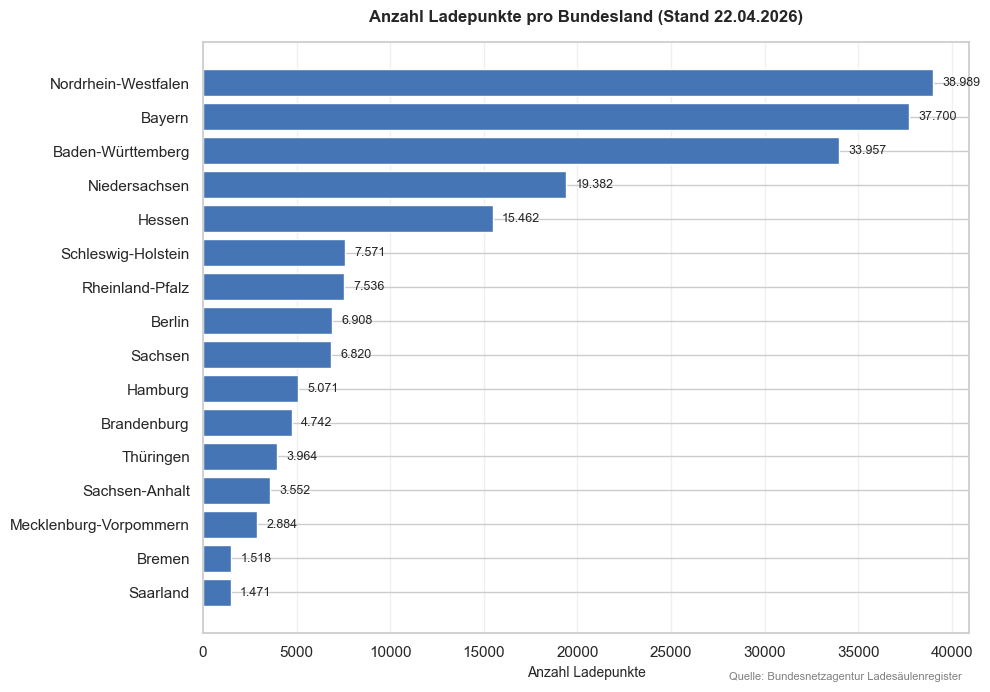

In [71]:
# --- Plot 1: Ladepunkte pro Bundesland ---
# Daten vorbereiten - aus versorgung-Tabelle, sortiert
plot_daten = versorgung.sort_values("Anzahl_Ladepunkte", ascending=True)

# Figure erstellen
fig, ax = plt.subplots(figsize=(10, 7))

# Horizontaler Balken (besser lesbar mit Bundesland-Labels)
ax.barh(plot_daten["Bundesland"], plot_daten["Anzahl_Ladepunkte"], color="#4575b4")

# Titel und Achsenbeschriftung
ax.set_title("Anzahl Ladepunkte pro Bundesland (Stand 22.04.2026)",
             fontweight="bold", pad=15)
ax.set_xlabel("Anzahl Ladepunkte")
ax.grid(axis="x", alpha=0.3)

# Werte rechts neben den Balken anzeigen
for i, (wert, name) in enumerate(zip(plot_daten["Anzahl_Ladepunkte"], plot_daten["Bundesland"])):
    ax.text(wert + 500, i, f"{int(wert):,}".replace(",", "."),
            va="center", fontsize=9)

# Quellenangabe unten rechts
ax.text(0.99, -0.08, "Quelle: Bundesnetzagentur Ladesäulenregister",
        transform=ax.transAxes, ha="right", fontsize=8, color="gray")

plt.tight_layout()

# Speichern und anzeigen
plt.savefig(f"{output_ordner}/01_ladepunkte_pro_bundesland.png", bbox_inches="tight")
plt.show()


### 6.3 Plot 2 — BEV-Trend Deutschland

Wir kombinieren absolute Stückzahlen (blaue Balken) mit dem prozentualen Anteil (rote Linie) über 15 Monate. Die `twinx()`-Funktion erlaubt zwei y-Achsen mit unterschiedlichen Skalen.

**Erkenntnis:** Der BEV-Anteil bei Neuzulassungen steigt von **~17% (Jan 2025) auf 24% (März 2026)**, mit einem absoluten Rekord von 70.618 BEV-Neuzulassungen im März 2026.

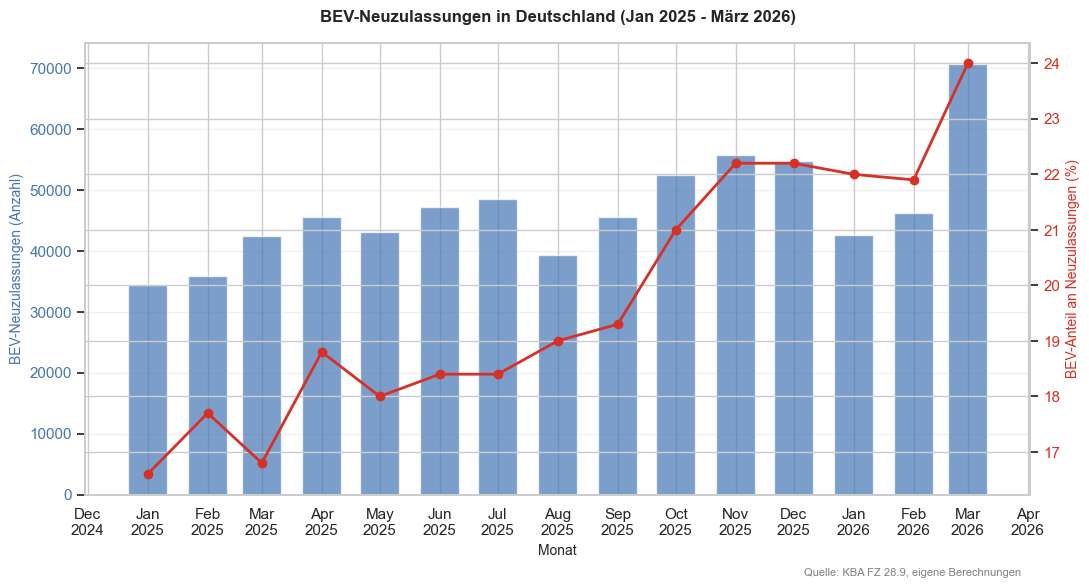

In [72]:
# --- Plot 2: BEV-Neuzulassungen Deutschland (15 Monate) ---
# Monatsweise Summen für ganz Deutschland berechnen
trend_de = (df_kba
    .groupby("Datum")
    .agg(
        BEV                   = ("BEV", "sum"),
        Neuzulassungen_gesamt = ("Neuzulassungen_gesamt", "sum"),
    )
    .reset_index()
)

# BEV-Anteil pro Monat berechnen
trend_de["BEV_Anteil_proz"] = (trend_de["BEV"] / trend_de["Neuzulassungen_gesamt"] * 100).round(1)

# Figure mit zwei y-Achsen erstellen (links: absolute BEVs, rechts: Anteil in %)
fig, ax1 = plt.subplots(figsize=(11, 6))

# Linke Achse: Absolute BEV-Zulassungen als Balken
ax1.bar(trend_de["Datum"], trend_de["BEV"],
        color="#4575b4", alpha=0.7, width=20, label="BEV-Neuzulassungen (absolut)")
ax1.set_xlabel("Monat")
ax1.set_ylabel("BEV-Neuzulassungen (Anzahl)", color="#4575b4")
ax1.tick_params(axis="y", labelcolor="#4575b4")
ax1.grid(axis="y", alpha=0.3)

# Rechte Achse: BEV-Anteil als Linie
ax2 = ax1.twinx()
ax2.plot(trend_de["Datum"], trend_de["BEV_Anteil_proz"],
         color="#d73027", marker="o", linewidth=2, label="BEV-Anteil (%)")
ax2.set_ylabel("BEV-Anteil an Neuzulassungen (%)", color="#d73027")
ax2.tick_params(axis="y", labelcolor="#d73027")

# Titel und Legende
ax1.set_title("BEV-Neuzulassungen in Deutschland (Jan 2025 - März 2026)",
              fontweight="bold", pad=15)

# Quellenangabe
ax1.text(0.99, -0.18, "Quelle: KBA FZ 28.9, eigene Berechnungen",
         transform=ax1.transAxes, ha="right", fontsize=8, color="gray")

# Datum-Formatierung auf X-Achse
import matplotlib.dates as mdates
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

plt.tight_layout()
plt.savefig(f"{output_ordner}/02_bev_trend_deutschland.png", bbox_inches="tight")
plt.show()

### 6.4 Plot 3 — Lader-Kategorien pro Bundesland

Ein gestapeltes Balkendiagramm zeigt nicht nur "wie viele" Ladepunkte ein Bundesland hat, sondern auch deren **Qualität** (Normallader / Schnelllader / HPC). Die Zahlen in den Segmenten machen die Größenverhältnisse direkt lesbar.

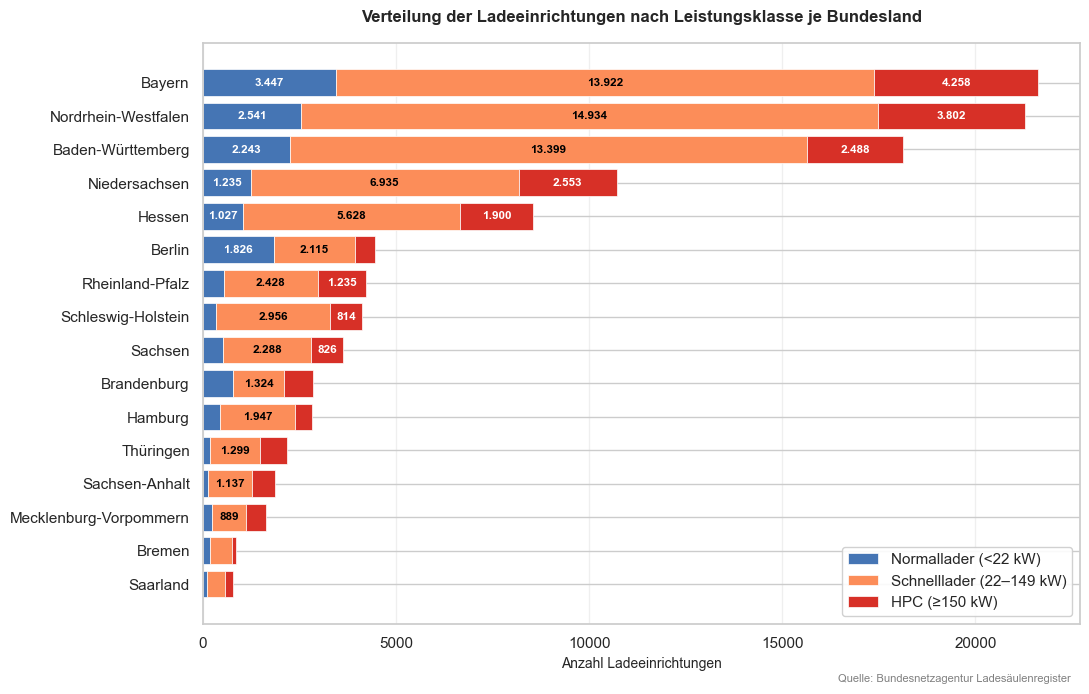

In [73]:
# --- Plot 3: Lader-Kategorien pro Bundesland (gestapelt) ---

# Daten nach Gesamtsumme sortieren (größtes Bundesland oben)
plot_daten = pivot_kategorie.copy()
plot_daten["Gesamt"] = plot_daten.sum(axis=1)
plot_daten = plot_daten.sort_values("Gesamt", ascending=True)
plot_daten = plot_daten.drop(columns=["Gesamt"])

# Spalten in sinnvolle Reihenfolge bringen: Normal -> Schnell -> HPC
spalten_reihenfolge = ["Normallader (<22 kW)", "Schnelllader (22–149 kW)", "HPC (≥150 kW)"]
plot_daten = plot_daten[spalten_reihenfolge]

# Figure
fig, ax = plt.subplots(figsize=(11, 7))

# Gestapelte horizontale Balken
links = [0] * len(plot_daten)   # Startposition jeder Schicht
for kategorie in spalten_reihenfolge:
    ax.barh(plot_daten.index,
            plot_daten[kategorie],
            left=links,
            color=farben_kategorie[kategorie],
            label=kategorie,
            edgecolor="white",
            linewidth=0.5)
    # Position für die nächste Schicht updaten
    links = [l + v for l, v in zip(links, plot_daten[kategorie])]

# --- Zahlen in die Segmente schreiben (nur wenn Segment groß genug) ---
links = [0] * len(plot_daten)   # nochmal von 0 starten

for kategorie in spalten_reihenfolge:
    for i, (laenge, start) in enumerate(zip(plot_daten[kategorie], links)):
        # Nur Zahl reinschreiben, wenn Segment groß genug ist (z.B. ≥ 800 Stk)
        if laenge >= 800:
            mitte = start + laenge / 2
            # Helle Schrift auf dunklem Rot/Blau, dunkle auf hellem Orange
            textfarbe = "white" if kategorie != "Schnelllader (22–149 kW)" else "black"
            ax.text(mitte, i, f"{int(laenge):,}".replace(",", "."),
                    ha="center", va="center", fontsize=8.5,
                    color=textfarbe, fontweight="bold")
    # Position für die nächste Schicht updaten
    links = [l + v for l, v in zip(links, plot_daten[kategorie])]

# Titel & Achsen
ax.set_title("Verteilung der Ladeeinrichtungen nach Leistungsklasse je Bundesland",
             fontweight="bold", pad=15)
ax.set_xlabel("Anzahl Ladeeinrichtungen")
ax.legend(loc="lower right", framealpha=0.9)
ax.grid(axis="x", alpha=0.3)

# Quellenangabe
ax.text(0.99, -0.10, "Quelle: Bundesnetzagentur Ladesäulenregister",
        transform=ax.transAxes, ha="right", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig(f"{output_ordner}/03_lader_kategorien_pro_bundesland.png", bbox_inches="tight")
plt.show()

### 6.5 Plot 4 — Streudiagramm: Ladepunkte vs. BEV-Bestand

Das Streudiagramm zeigt die **lineare Beziehung** zwischen Infrastruktur und E-Auto-Bestand. Die Trendlinie wird per `np.polyfit` (lineare Regression, Polynom 1. Grades) berechnet.

**Erkenntnis:** Im Durchschnitt kommen **11 BEVs auf einen Ladepunkt** (Steigung der Trendlinie). NRW liegt auffällig über der Linie (unterversorgt), kleine Stadtstaaten darunter (gut versorgt).

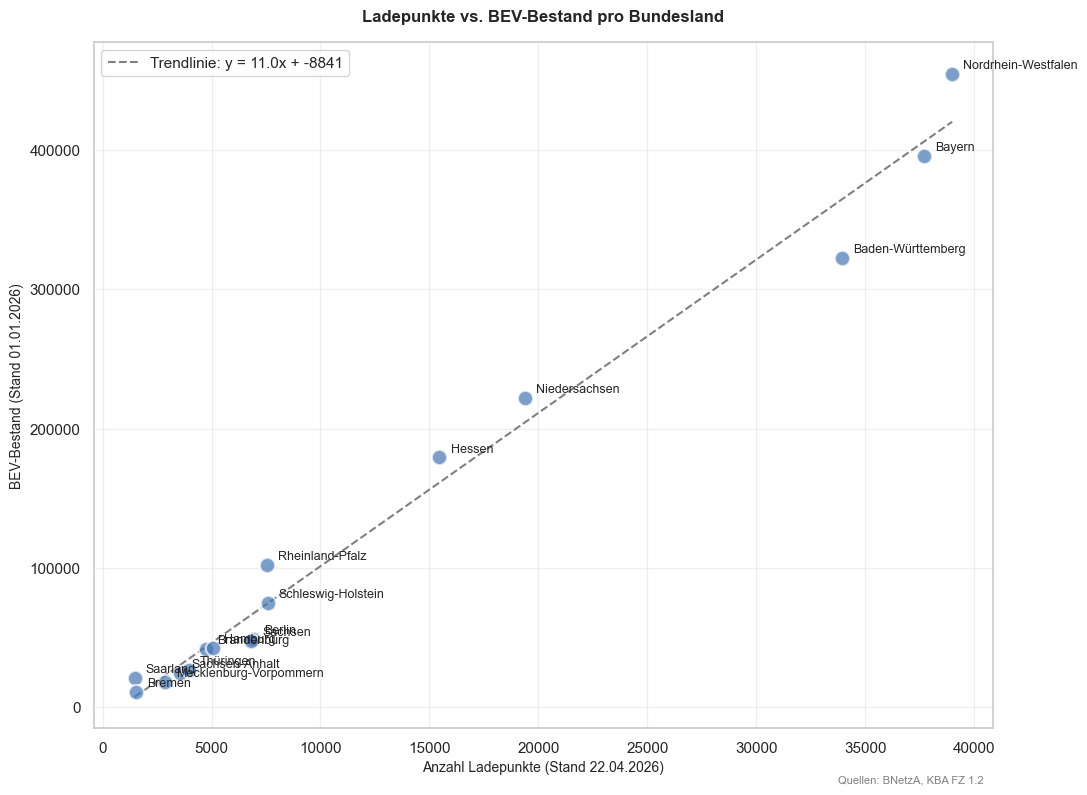

In [74]:
# --- Plot 4: Streudiagramm Ladepunkte vs. BEV-Bestand ---

fig, ax = plt.subplots(figsize=(11, 8))

# Streupunkte zeichnen
ax.scatter(versorgung["Anzahl_Ladepunkte"],
           versorgung["BEV_Bestand"],
           s=120,                       # Punktgröße
           color="#4575b4",
           alpha=0.7,
           edgecolor="white",
           linewidth=1.5,
           zorder=3)                    # Punkte über das Grid

# Beschriftung jedes Punkts mit Bundesland-Namen
for _, zeile in versorgung.iterrows():
    ax.annotate(zeile["Bundesland"],
                xy=(zeile["Anzahl_Ladepunkte"], zeile["BEV_Bestand"]),
                xytext=(8, 4),           # 8 Pixel rechts, 4 hoch
                textcoords="offset points",
                fontsize=9)

# Trendlinie (lineare Regression mit np.polyfit - Kursmaterial Tag 6)
import numpy as np
x = versorgung["Anzahl_Ladepunkte"].values
y = versorgung["BEV_Bestand"].values
koeff = np.polyfit(x, y, 1)               # 1 = linear
x_linie = np.linspace(x.min(), x.max(), 100)
y_linie = np.polyval(koeff, x_linie)
ax.plot(x_linie, y_linie,
        color="gray", linestyle="--", linewidth=1.5,
        label=f"Trendlinie: y = {koeff[0]:.1f}x + {koeff[1]:.0f}",
        zorder=2)

# Titel & Achsen
ax.set_title("Ladepunkte vs. BEV-Bestand pro Bundesland",
             fontweight="bold", pad=15)
ax.set_xlabel("Anzahl Ladepunkte (Stand 22.04.2026)")
ax.set_ylabel("BEV-Bestand (Stand 01.01.2026)")
ax.grid(alpha=0.3)
ax.legend(loc="upper left")

# Quellenangabe
ax.text(0.99, -0.08, "Quellen: BNetzA, KBA FZ 1.2",
        transform=ax.transAxes, ha="right", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig(f"{output_ordner}/04_scatter_ladepunkte_vs_bev.png", bbox_inches="tight")
plt.show()

### 6.6 Plot 5 — BEV-Anteil: Bestand vs. Neuzulassungen

Gruppierte Balken zeigen den Unterschied zwischen "was schon da ist" (Bestand) und "was gerade neu kommt" (Neuzulassungen).

**Erkenntnis:** Überall in Deutschland klafft eine **starke Lücke** zwischen Bestand (~2-5%) und Neuzulassungen (~13-22%). Der Fuhrpark elektrifiziert sich rasant — wenn das Neuzulassungs-Tempo bleibt, wird der Bestands-Anteil in den kommenden Jahren stark wachsen.

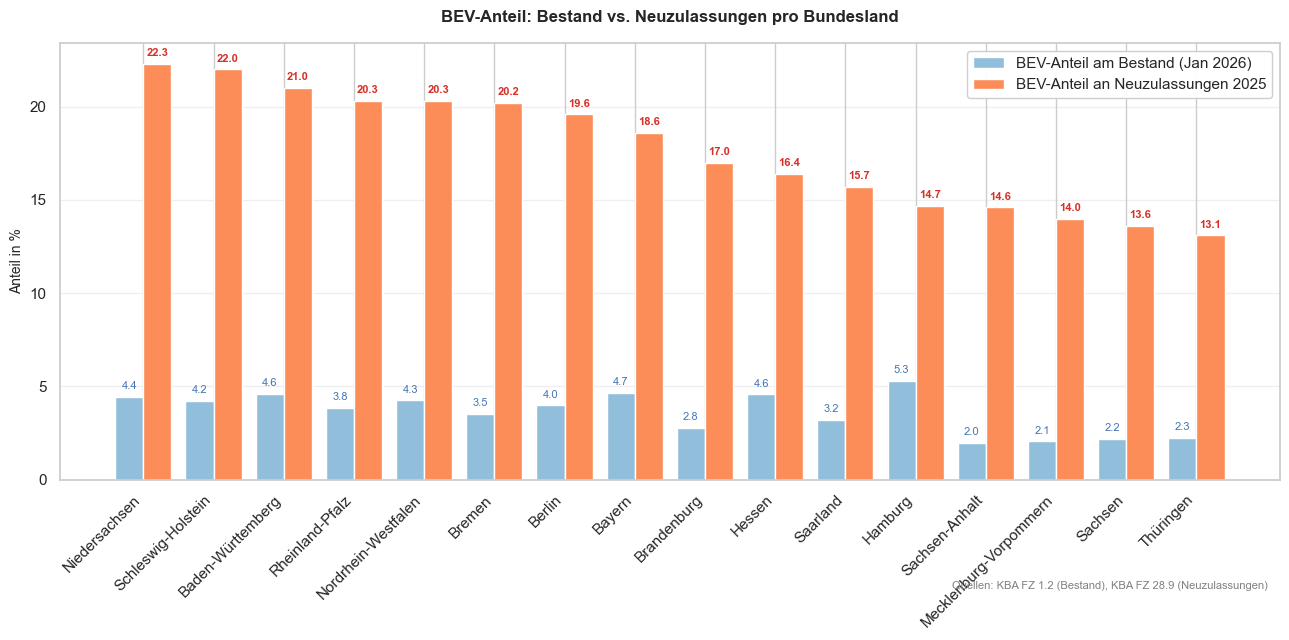

In [75]:
# --- Plot 5: BEV-Anteil Bestand vs. Neuzulassungen (gruppiert) ---

# Daten sortieren nach Neuzulassungs-Anteil (höchster zuerst, links)
plot_daten = versorgung.sort_values("BEV_Anteil_Neuzul_%", ascending=False).copy()

# Positionen auf der X-Achse
x = np.arange(len(plot_daten))
breite = 0.4

# Figure
fig, ax = plt.subplots(figsize=(13, 6.5))

# Zwei Balken-Gruppen nebeneinander
balken1 = ax.bar(x - breite/2, plot_daten["BEV_Anteil_am_Bestand_%"],
                 width=breite, label="BEV-Anteil am Bestand (Jan 2026)",
                 color="#91bfdb", edgecolor="white")

balken2 = ax.bar(x + breite/2, plot_daten["BEV_Anteil_Neuzul_%"],
                 width=breite, label="BEV-Anteil an Neuzulassungen 2025",
                 color="#fc8d59", edgecolor="white")

# Werte über die Balken schreiben
for bar in balken1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
            f"{h:.1f}", ha="center", va="bottom", fontsize=8, color="#4575b4")

for bar in balken2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
            f"{h:.1f}", ha="center", va="bottom", fontsize=8, color="#d73027", fontweight="bold")

# Achsen-Beschriftung
ax.set_xticks(x)
ax.set_xticklabels(plot_daten["Bundesland"], rotation=45, ha="right")
ax.set_ylabel("Anteil in %")
ax.set_title("BEV-Anteil: Bestand vs. Neuzulassungen pro Bundesland",
             fontweight="bold", pad=15)

ax.legend(loc="upper right", framealpha=0.95)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)   # Grid hinter die Balken

# Quellenangabe
ax.text(0.99, -0.25, "Quellen: KBA FZ 1.2 (Bestand), KBA FZ 28.9 (Neuzulassungen)",
        transform=ax.transAxes, ha="right", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig(f"{output_ordner}/05_anteil_bestand_vs_neuzulassungen.png", bbox_inches="tight")
plt.show()

### 6.7 Plot 6 — Korrelations-Heatmap

Die Korrelationsmatrix (Pearson) zeigt, wie stark die Kennzahlen miteinander zusammenhängen.

**Erkenntnis:** Die meisten **absoluten Kennzahlen** (Ladepunkte, BEV-Bestand, Pkw-Bestand) korrelieren sehr stark miteinander (~0,98–1,00) — sie skalieren alle mit der Bundesland-Größe. Die **relativen Kennzahlen** (Anteile, Versorgungsgrad) zeigen niedrigere Korrelationen — sie sind unabhängig von der Größe und erzählen eigene Geschichten.

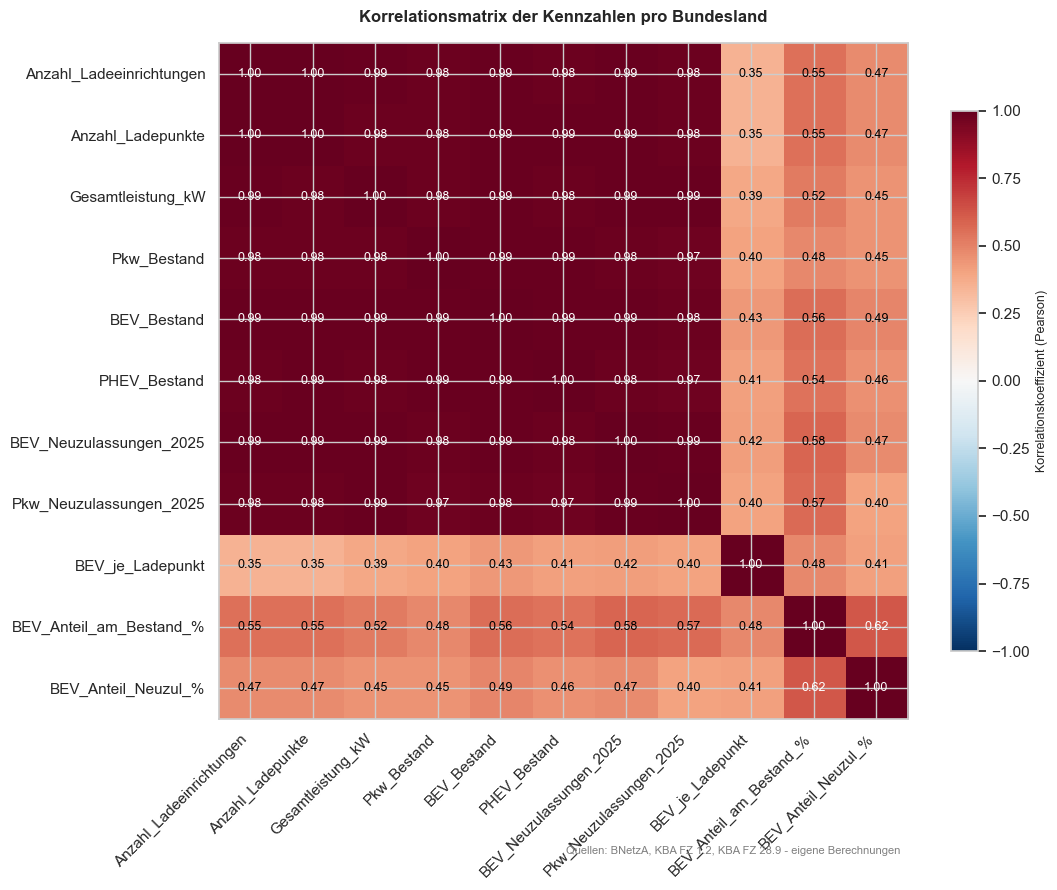

In [76]:
# --- Plot 6: Korrelations-Heatmap ---

# Nur numerische Spalten für Korrelation auswählen
# (Bundesland-Spalte ist Text und fällt automatisch raus)
numerische_spalten = [
    "Anzahl_Ladeeinrichtungen",
    "Anzahl_Ladepunkte",
    "Gesamtleistung_kW",
    "Pkw_Bestand",
    "BEV_Bestand",
    "PHEV_Bestand",
    "BEV_Neuzulassungen_2025",
    "Pkw_Neuzulassungen_2025",
    "BEV_je_Ladepunkt",
    "BEV_Anteil_am_Bestand_%",
    "BEV_Anteil_Neuzul_%",
]

# Korrelations-Matrix berechnen
korr = versorgung[numerische_spalten].corr().round(2)

# Figure
fig, ax = plt.subplots(figsize=(11, 9))

# Heatmap zeichnen
im = ax.imshow(korr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

# Achsen-Beschriftung
ax.set_xticks(range(len(numerische_spalten)))
ax.set_yticks(range(len(numerische_spalten)))
ax.set_xticklabels(numerische_spalten, rotation=45, ha="right")
ax.set_yticklabels(numerische_spalten)

# Werte in die Zellen schreiben
for i in range(len(numerische_spalten)):
    for j in range(len(numerische_spalten)):
        wert = korr.values[i, j]
        # Helle Schrift bei starken Korrelationen, dunkle bei schwachen
        textfarbe = "white" if abs(wert) > 0.6 else "black"
        ax.text(j, i, f"{wert:.2f}", ha="center", va="center",
                fontsize=9, color=textfarbe)

# Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Korrelationskoeffizient (Pearson)", fontsize=9)

# Titel
ax.set_title("Korrelationsmatrix der Kennzahlen pro Bundesland",
             fontweight="bold", pad=15)

# Quellenangabe
ax.text(0.99, -0.20, "Quellen: BNetzA, KBA FZ 1.2, KBA FZ 28.9 - eigene Berechnungen",
        transform=ax.transAxes, ha="right", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig(f"{output_ordner}/06_korrelations_heatmap.png", bbox_inches="tight")
plt.show()

### 6.8 Plot 7 — Dashboard im gridspec-Stil

Wir kombinieren die wichtigsten Visualisierungen auf einer Seite. Mit `matplotlib.gridspec` lassen sich Subplots flexibel anordnen — die obere Reihe nimmt die volle Breite ein, darunter folgen zwei Spalten.

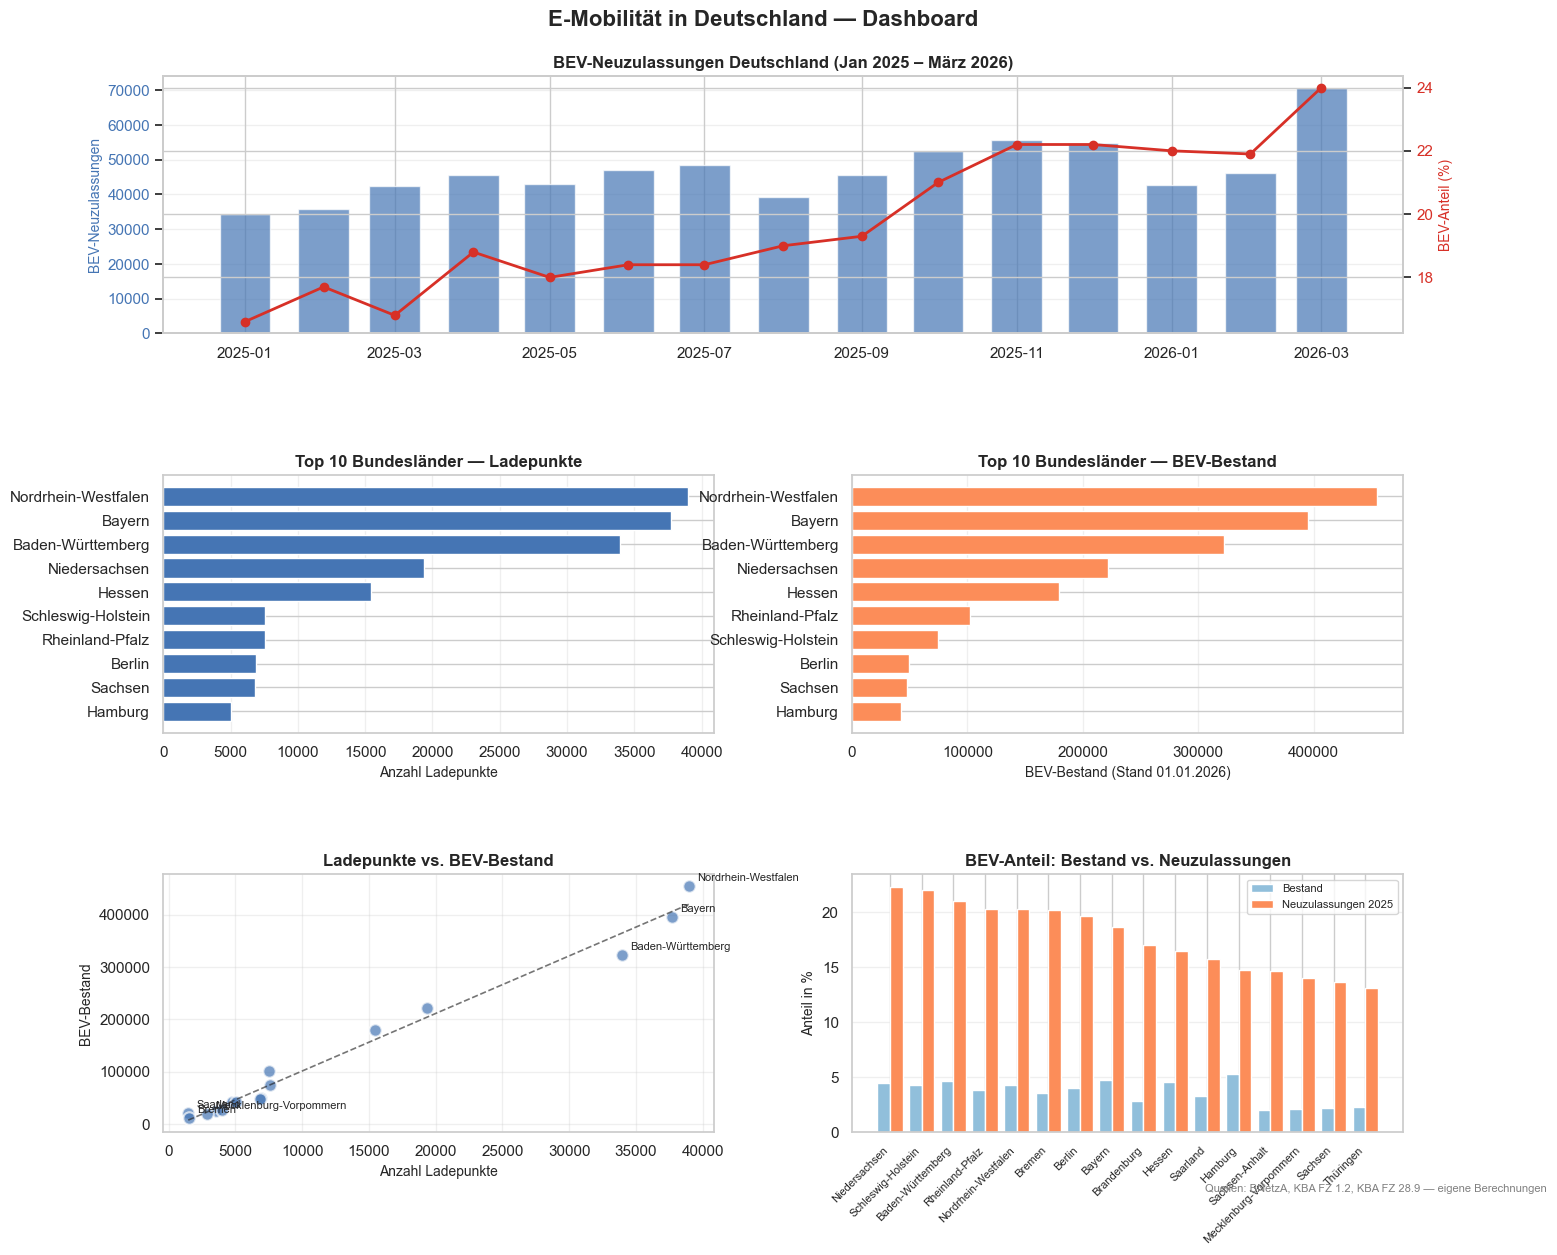

In [77]:
# --- Plot 7: Dashboard im gridspec-Stil ---
import matplotlib.gridspec as gridspec

# Figure mit großem Format (Querformat, eher für Bildschirm/Folie)
fig = plt.figure(figsize=(16, 12))
fig.suptitle("E-Mobilität in Deutschland — Dashboard",
             fontsize=16, fontweight="bold", y=0.995)

# Gridspec: 3 Reihen × 2 Spalten, Reihe 1 = ganze Breite (über zwei Spalten)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.25,
                       top=0.94, bottom=0.06)

# ========== (1) Reihe 1: BEV-Trend Deutschland (ganze Breite) ==========
ax1 = fig.add_subplot(gs[0, :])   # Reihe 0, alle Spalten

trend_de = (df_kba
    .groupby("Datum")
    .agg(BEV=("BEV", "sum"),
         Gesamt=("Neuzulassungen_gesamt", "sum"))
    .reset_index()
)
trend_de["Anteil"] = (trend_de["BEV"] / trend_de["Gesamt"] * 100).round(1)

ax1.bar(trend_de["Datum"], trend_de["BEV"], color="#4575b4", alpha=0.7, width=20)
ax1.set_ylabel("BEV-Neuzulassungen", color="#4575b4")
ax1.tick_params(axis="y", labelcolor="#4575b4")
ax1.set_title("BEV-Neuzulassungen Deutschland (Jan 2025 – März 2026)",
              fontweight="bold")
ax1.grid(axis="y", alpha=0.3)

ax1b = ax1.twinx()
ax1b.plot(trend_de["Datum"], trend_de["Anteil"],
          color="#d73027", marker="o", linewidth=2)
ax1b.set_ylabel("BEV-Anteil (%)", color="#d73027")
ax1b.tick_params(axis="y", labelcolor="#d73027")

# ========== (2) Reihe 2 Links: Top 10 Bundesländer Ladepunkte ==========
ax2 = fig.add_subplot(gs[1, 0])
top10_lp = versorgung.sort_values("Anzahl_Ladepunkte", ascending=True).tail(10)
ax2.barh(top10_lp["Bundesland"], top10_lp["Anzahl_Ladepunkte"], color="#4575b4")
ax2.set_title("Top 10 Bundesländer — Ladepunkte", fontweight="bold")
ax2.set_xlabel("Anzahl Ladepunkte")
ax2.grid(axis="x", alpha=0.3)

# ========== (3) Reihe 2 Rechts: Top 10 Bundesländer BEV-Bestand ==========
ax3 = fig.add_subplot(gs[1, 1])
top10_bev = versorgung.sort_values("BEV_Bestand", ascending=True).tail(10)
ax3.barh(top10_bev["Bundesland"], top10_bev["BEV_Bestand"], color="#fc8d59")
ax3.set_title("Top 10 Bundesländer — BEV-Bestand", fontweight="bold")
ax3.set_xlabel("BEV-Bestand (Stand 01.01.2026)")
ax3.grid(axis="x", alpha=0.3)

# ========== (4) Reihe 3 Links: Scatter Ladepunkte vs. BEV-Bestand ==========
ax4 = fig.add_subplot(gs[2, 0])
ax4.scatter(versorgung["Anzahl_Ladepunkte"], versorgung["BEV_Bestand"],
            s=80, color="#4575b4", alpha=0.7, edgecolor="white", linewidth=1.5)

# Trendlinie
x = versorgung["Anzahl_Ladepunkte"].values
y = versorgung["BEV_Bestand"].values
koeff = np.polyfit(x, y, 1)
x_lin = np.linspace(x.min(), x.max(), 100)
ax4.plot(x_lin, np.polyval(koeff, x_lin), "k--", linewidth=1.2, alpha=0.6)

# Nur die Top 3 + Bottom 3 beschriften (sonst überlappt zu viel)
auffaellige = pd.concat([versorgung.nlargest(3, "BEV_Bestand"),
                          versorgung.nsmallest(3, "BEV_Bestand")])
for _, zeile in auffaellige.iterrows():
    ax4.annotate(zeile["Bundesland"],
                 xy=(zeile["Anzahl_Ladepunkte"], zeile["BEV_Bestand"]),
                 xytext=(6, 4), textcoords="offset points", fontsize=8)

ax4.set_title("Ladepunkte vs. BEV-Bestand", fontweight="bold")
ax4.set_xlabel("Anzahl Ladepunkte")
ax4.set_ylabel("BEV-Bestand")
ax4.grid(alpha=0.3)

# ========== (5) Reihe 3 Rechts: Bestand vs. Neuzulassungen ==========
ax5 = fig.add_subplot(gs[2, 1])
plot_daten = versorgung.sort_values("BEV_Anteil_Neuzul_%", ascending=False)
x_pos = np.arange(len(plot_daten))
breite = 0.4

ax5.bar(x_pos - breite/2, plot_daten["BEV_Anteil_am_Bestand_%"],
        width=breite, label="Bestand", color="#91bfdb")
ax5.bar(x_pos + breite/2, plot_daten["BEV_Anteil_Neuzul_%"],
        width=breite, label="Neuzulassungen 2025", color="#fc8d59")

ax5.set_xticks(x_pos)
ax5.set_xticklabels(plot_daten["Bundesland"], rotation=45, ha="right", fontsize=8)
ax5.set_ylabel("Anteil in %")
ax5.set_title("BEV-Anteil: Bestand vs. Neuzulassungen", fontweight="bold")
ax5.legend(loc="upper right", fontsize=8)
ax5.grid(axis="y", alpha=0.3)
ax5.set_axisbelow(True)

# Gemeinsame Quellenangabe unten
fig.text(0.99, 0.01, "Quellen: BNetzA, KBA FZ 1.2, KBA FZ 28.9 — eigene Berechnungen",
         ha="right", fontsize=8, color="gray")

plt.savefig(f"{output_ordner}/07_dashboard.png", bbox_inches="tight", dpi=140)
plt.show()

### 6.9 Plot 8 — Seaborn-Heatmap: Bundesländer × Kennzahlen

Diese Heatmap (mit **Seaborn** statt rein Matplotlib) zeigt auf einen Blick, **wo jedes Bundesland bei welcher Kennzahl steht**.

**Technischer Trick:** Min-Max-Normalisierung pro Spalte — so können wir Kennzahlen mit völlig unterschiedlichen Skalen (38.989 Ladepunkte vs. 4,67% BEV-Anteil) fair miteinander vergleichen. Die Zellfarbe zeigt die relative Position, die Beschriftung zeigt den echten Wert.

**Story-Highlights:**
- **Niedersachsen, Schleswig-Holstein** durchgehend grün-stark bei BEV-Anteilen
- **NRW, Bayern, Baden-Württemberg** dominieren bei absoluten Zahlen
- **Hamburg** mit höchstem Bestand-Anteil (5,3%)
- **Saarland** mit höchstem Versorgungsdruck (14,3 BEVs pro Ladepunkt)
- **Ostdeutsche Flächenländer** durchgehend rot bei BEV-Quoten

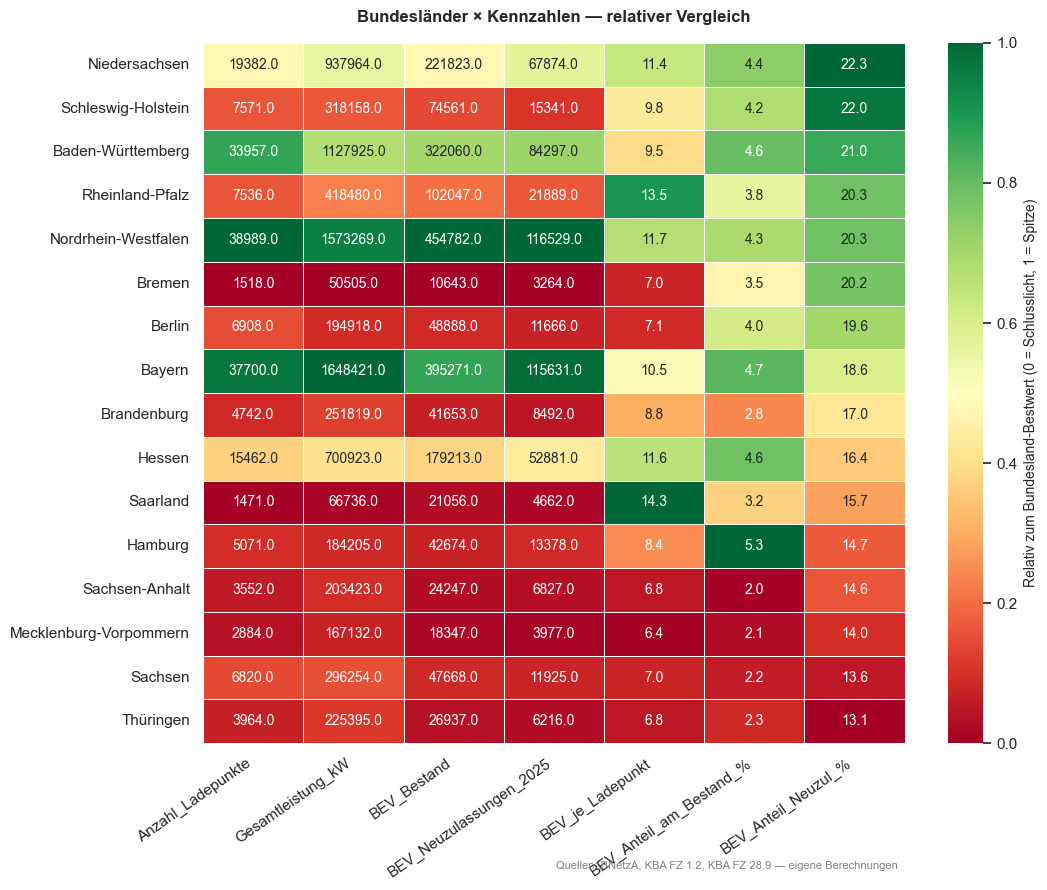

In [78]:
# --- Plot 8 (Seaborn): Bundesländer × Kennzahl-Heatmap ---
import seaborn as sns

# Spalten auswählen, die wir vergleichen wollen
spalten = [
    "Anzahl_Ladepunkte",
    "Gesamtleistung_kW",
    "BEV_Bestand",
    "BEV_Neuzulassungen_2025",
    "BEV_je_Ladepunkt",
    "BEV_Anteil_am_Bestand_%",
    "BEV_Anteil_Neuzul_%",
]

# Daten vorbereiten - Bundesland als Index, nur ausgewählte Spalten
heatmap_daten = versorgung.set_index("Bundesland")[spalten]

# Sortierung nach BEV-Anteil bei Neuzulassungen (interessanteste Kennzahl oben)
heatmap_daten = heatmap_daten.sort_values("BEV_Anteil_Neuzul_%", ascending=False)

# Min-Max-Normalisierung pro Spalte (0 = schwächstes Bundesland, 1 = stärkstes)
heatmap_norm = (heatmap_daten - heatmap_daten.min()) / (heatmap_daten.max() - heatmap_daten.min())

# Figure
fig, ax = plt.subplots(figsize=(11, 9))

# Seaborn Heatmap
sns.heatmap(
    heatmap_norm,
    annot=heatmap_daten.round(1),    # Echte Werte als Beschriftung (nicht die normalisierten!)
    fmt=".1f",                        # 1 Nachkommastelle
    cmap="RdYlGn",                    # Rot-Gelb-Grün
    cbar_kws={"label": "Relativ zum Bundesland-Bestwert (0 = Schlusslicht, 1 = Spitze)"},
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

ax.set_title("Bundesländer × Kennzahlen — relativer Vergleich",
             fontweight="bold", pad=15)
ax.set_xlabel("")
ax.set_ylabel("")

# X-Achsen-Labels schräg
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)

# Quellenangabe
ax.text(0.99, -0.18, "Quellen: BNetzA, KBA FZ 1.2, KBA FZ 28.9 — eigene Berechnungen",
        transform=ax.transAxes, ha="right", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig(f"{output_ordner}/08_seaborn_bundeslaender_kennzahlen.png", bbox_inches="tight")
plt.show()

---

## 7. Erkenntnisse & Diskussion

### 7.1 Hauptbefunde

**1. Drei-Länder-Dominanz bei der Infrastruktur.**  
NRW (38.989), Bayern (37.700) und Baden-Württemberg (33.957) stellen zusammen über **50% aller öffentlichen Ladepunkte** in Deutschland. Die kleinen Bundesländer (Saarland 1.471, Bremen 1.518, Mecklenburg-Vorpommern 2.884) liegen mehr als eine Größenordnung darunter.

**2. Der E-Mobilitäts-Markt wächst stark und nachhaltig.**  
Über den Zeitraum Jan 2025 – März 2026 wächst der BEV-Anteil an Neuzulassungen von 17% auf 24%. Der absolute Rekord wird im März 2026 mit 70.618 BEVs erreicht — fast doppelt so viel wie im Januar 2025 (34.000).

**3. Bestand und Neuzulassungen klaffen stark auseinander.**  
Der BEV-Anteil am bestehenden Fuhrpark liegt deutschlandweit bei 2-5%, der Anteil bei Neuzulassungen 2025 dagegen bei 13-22%. Diese Lücke zeigt: Die Elektrifizierung läuft, ist aber durch die lange Halbwertszeit von Autos noch nicht im Bestand sichtbar.

**4. Ein klares Ost-West-Gefälle.**  
Sachsen-Anhalt (2,0%), Mecklenburg-Vorpommern (2,1%), Sachsen (2,2%) und Thüringen (2,3%) bilden das Schlusslicht beim BEV-Anteil am Bestand. Niedersachsen (4,4%), Schleswig-Holstein (4,2%) und Baden-Württemberg (4,6%) führen — gepaart mit den stärksten Neuzulassungs-Quoten.

**5. Lineare Beziehung Infrastruktur ↔ Bestand.**  
Die Trendlinie aus dem Streudiagramm zeigt: Pro zusätzlichem Ladepunkt kommen ~11 BEVs. Diese Relation hält über alle Bundesländer hinweg überraschend stabil — mit NRW als auffälligem Ausreißer nach oben (unterversorgt).

### 7.2 Eigene Kennzahlen — was sie zeigen

| Kennzahl | Sieger | Schlusslicht | Aussagekraft |
|---|---|---|---|
| BEV je Ladepunkt | MV (6,4) | Saarland (14,3) | Versorgungsdruck (niedrig = gut) |
| BEV-Anteil Bestand (%) | Hamburg (5,3) | Sachsen-Anhalt (2,0) | Ist-Stand der E-Mobilität |
| BEV-Anteil Neuzul. (%) | Niedersachsen (22,3) | Thüringen (13,1) | Aktuelle Marktdynamik |

### 7.3 Methodische Anmerkungen

- **Versorgungsgrad mit Bestand statt Neuzulassungen.** Wir nutzen `BEV-Bestand / Ladepunkte`, weil das die Realität der Nutzung abbildet (Bestand fährt = lädt). Eine Berechnung über Neuzulassungen würde unterschätzen, wie viele E-Autos tatsächlich auf der Straße sind.
- **Kalenderjahr 2025 für Bundesländer-Vergleiche.** Wir nutzen die 12 abgeschlossenen Monate des KJ 2025, nicht den Zeitraum bis März 2026 — das macht die Bundesländer-Anteile vergleichbar zwischen den Quellen.
- **Bundesländer-Schreibweise harmonisiert.** KBA ("Baden-Wuerttemberg") und BNetzA ("Baden-Württemberg") wurden über ein Mapping vereinheitlicht.

---

## 8. Limitationen & Ausblick

### 8.1 Limitationen

- **Nur öffentliche Ladepunkte.** Private Wallboxen (laut Schätzungen 700.000+ in Deutschland) sind nicht im BNetzA-Register erfasst. Der reale Ladeumfang ist deutlich größer.
- **Bestandsstichtag.** Der BEV-Bestand bezieht sich auf den 01.01.2026, die Ladepunkte auf den 22.04.2026 — eine kleine Inkonsistenz von ca. 4 Monaten.
- **Keine Nutzungs-Daten.** Wir wissen, wie viele Ladepunkte existieren, aber nicht, wie ausgelastet sie sind.
- **Keine Pendler-Dynamik.** BEVs werden in ihrem Wohnort-Bundesland registriert, geladen wird aber oft im Pendel-Ziel. Stadtstaaten könnten dadurch verzerrt wirken.

### 8.2 Ausblick: Mögliche Weiterführungen

- **Lineare Regression für Prognose.** Mit `np.polyfit` ließe sich der BEV-Anteil-Trend extrapolieren — ab wann erreichen wir 50% BEV-Anteil bei Neuzulassungen?
- **FZ 2.0 — BEV nach Hersteller.** Welche Marken sind Marktführer? Auswertung der Hersteller-Statistik FZ 2.0.
- **Geografische Visualisierung.** Eine Choroplethen-Karte mit `geopandas` würde die regionalen Muster geographisch sichtbar machen.
- **Verknüpfung mit Bevölkerungs-Daten.** Ladepunkte / 1.000 Einwohner statt absoluter Zahlen — fairerer Vergleich zwischen Stadt- und Flächenländern.

---

## Reproduzierbarkeit

Dieses Notebook ist reproduzierbar mit:

- Python ≥ 3.10
- Bibliotheken aus `requirements.txt`
- Daten im Verzeichnis `data/` (BNetzA-CSV und KBA-Excel-Dateien)

Zur Ausführung: Kernel auf `.venv` setzen, alle Zellen von oben nach unten ausführen (Run All).
